# MAQT & Empirical Robustness (FGSM / PGD)
## UNSW-NB15 | Reuse Day-16 Checkpoint | Target (y) = "label_multiclass" | Data Reupload = 2 | 300 Known-Accepted Test Samples | Breakpoint 0.99

### Scope:

- load frozen MAQT encoder ($\theta^\star$, prototypes) + $L_\varphi$
- calibrate conformal $q$ on the known calibration split (for accept/reject)
- attack the novelty score $s(x)=1-F_{\max}(x)$ with FGSM and PGD (Prop-2-faithful)
- record acceptance rate and robust accuracy vs $\varepsilon_\infty$ / $\varepsilon_2$
- locate the empirical breakpoint (known samples start being misflagged)

### Note:

Classifier-head CE attacks (`scripts.attacks`) need a trained head. Day-16 checkpoints are prototype-centric, so this notebook uses `fgsm_attack_nonconformity` / `pgd_attack_nonconformity` from `scripts.theory`.

## Setup

In [1]:
import pennylane as qp
from pennylane import numpy as np
import torch

import matplotlib.pyplot as plt
import pandas as pd

from pathlib import Path
import time

In [2]:
from scripts.constants import (
    DEFAULT_LR, DEFAULT_BATCH_SIZE,
    DEFAULT_LAMBDA1, DEFAULT_LAMBDA2, DEFAULT_NOISE_RATE,
    DEFAULT_CF, DEFAULT_ALPHA, ZERO_DAY, INPUT_DIM_D,
)
from scripts.data import (
    capped_sample,
    load_split,
    plot_class_balance_pie,
)
from scripts.circuit import build_forward_circuit, create_quantum_device
from scripts.train import train_maqt
from scripts.utils import get_torch_device, to_np_y, to_torch_batch_x
from scripts.logging import write_history_log
from scripts.prototypes import prototype_summary
from scripts.conformal import calibrate_threshold
from scripts.inference import qsnet_infer_batch
from scripts.quantum_metrics import stack_prototypes
from scripts.theory import (
    fgsm_attack_nonconformity,
    pgd_attack_nonconformity,
    linf_to_l2_budget,
)

In [3]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available?: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA device name: {torch.cuda.get_device_name(0)}")
    print(f"Current CUDA device index: {torch.cuda.current_device()}")

PyTorch version: 2.12.1+cu126
CUDA available?: True
CUDA device name: NVIDIA GeForce GTX 1060
Current CUDA device index: 0


## Load Dataset: UNSW-NB15

In [4]:
NOTEBOOK_NAME = "19.fgsm-pgd-robustness_unsw-nb15"
DAY16_NOTEBOOK = "16.estimate-lipschitz_unsw-nb15"
DAY18_NOTEBOOK = "18.fin-fout-epsstar_unsw-nb15"
dataset = "UNSW-NB15"
split_prefix = "q8"
target_col = "label_multiclass"
data_path = f"data/{dataset}/quantum"

In [5]:
df = pd.read_parquet(f"{data_path}/{split_prefix}_train.parquet")
df

,rate_dst,iat,rate,rate_src,duration,dst_bytes,conn_state,dst_pkts,label_multiclass,label_binary,label_family
0,2.660748,1.000199,1.193106,1.289150,1.240526,2.600926,3.141593,2.190781,Exploits,1,exploits
1,1.300715,1.148865,0.717575,1.401026,0.207269,0.850290,0.374600,0.370983,Normal,0,benign
2,0.000000,0.002482,2.641954,2.489562,0.000007,0.000000,0.168227,0.000000,Generic,1,generic
3,1.547429,1.337109,0.657683,1.161471,0.572600,1.232307,3.141593,0.809729,Normal,0,benign
4,2.342302,0.643438,1.282489,1.506876,0.034630,1.447465,3.141593,0.741966,Normal,0,benign
...,...,...,...,...,...,...,...,...,...,...,...
71089,1.413310,1.351137,0.614096,1.217883,0.610868,1.118026,3.141593,0.741966,Exploits,1,exploits
71090,1.808522,1.157237,0.776405,1.294835,0.348747,1.380490,3.141593,0.741966,DoS,1,dos
71091,2.636567,0.979324,1.179932,1.310244,0.758969,2.410352,3.141593,1.868532,Exploits,1,exploits
71092,1.803881,0.954620,0.931850,1.601995,0.431998,1.412047,3.141593,1.028084,Exploits,1,exploits


In [6]:
# check rows if NaN dropped
df[df[target_col].notna()].copy()

,rate_dst,iat,rate,rate_src,duration,dst_bytes,conn_state,dst_pkts,label_multiclass,label_binary,label_family
0,2.660748,1.000199,1.193106,1.289150,1.240526,2.600926,3.141593,2.190781,Exploits,1,exploits
1,1.300715,1.148865,0.717575,1.401026,0.207269,0.850290,0.374600,0.370983,Normal,0,benign
2,0.000000,0.002482,2.641954,2.489562,0.000007,0.000000,0.168227,0.000000,Generic,1,generic
3,1.547429,1.337109,0.657683,1.161471,0.572600,1.232307,3.141593,0.809729,Normal,0,benign
4,2.342302,0.643438,1.282489,1.506876,0.034630,1.447465,3.141593,0.741966,Normal,0,benign
...,...,...,...,...,...,...,...,...,...,...,...
71089,1.413310,1.351137,0.614096,1.217883,0.610868,1.118026,3.141593,0.741966,Exploits,1,exploits
71090,1.808522,1.157237,0.776405,1.294835,0.348747,1.380490,3.141593,0.741966,DoS,1,dos
71091,2.636567,0.979324,1.179932,1.310244,0.758969,2.410352,3.141593,1.868532,Exploits,1,exploits
71092,1.803881,0.954620,0.931850,1.601995,0.431998,1.412047,3.141593,1.028084,Exploits,1,exploits


In [7]:
# get labels
class_names = sorted(df[target_col].dropna().unique())
class_names

['Analysis',
 'Backdoor',
 'DoS',
 'Exploits',
 'Fuzzers',
 'Generic',
 'Normal',
 'Reconnaissance']

In [8]:
# load full dataset (known classes only)
X_train_full, y_train_full = load_split(data_path, f"{split_prefix}_train", target_col, class_names)
X_cal, y_cal = load_split(data_path, f"{split_prefix}_calibration", target_col, class_names)
X_test, y_test = load_split(data_path, f"{split_prefix}_test", target_col, class_names)

In [9]:
# check shape
[X_train_full.shape, y_train_full.shape, X_cal.shape, y_cal.shape, X_test.shape, y_test.shape]

[(71094, 8), (71094,), (10112, 8), (10112,), (10086, 8), (10086,)]

## EDA (Before Subset)

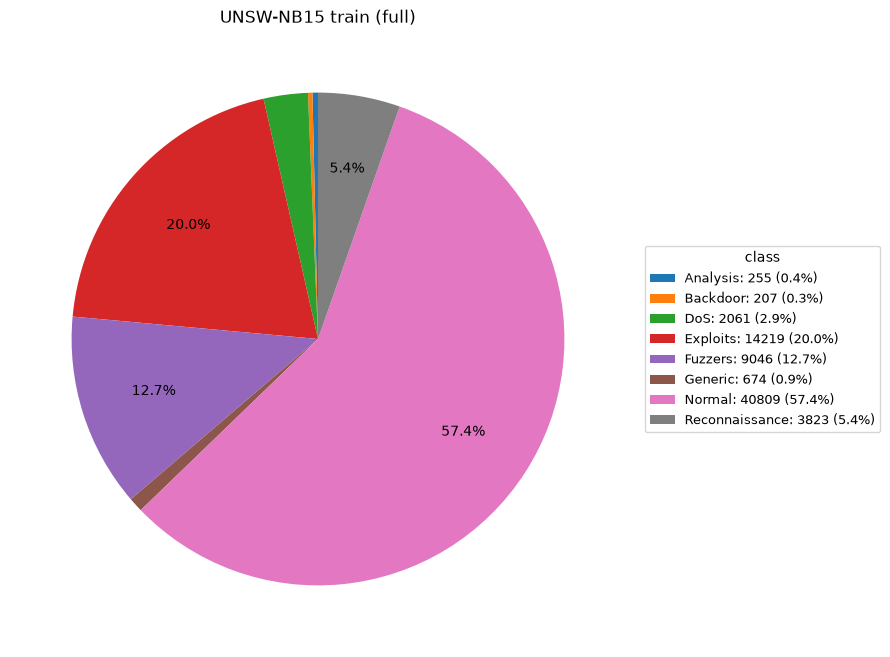

In [10]:
# pie chart
_ = plot_class_balance_pie(y_train_full, class_names, title=f"{dataset} train (full)")
plt.show()

## Data Subset

In [11]:
SUBSET = True  # set to False for the full dataset
SEED = 42
PER_CLASS_CAP = 400  # matches Day-16 UNSW-NB15 protocol

In [12]:
if SUBSET is True:
    X_train, y_train = capped_sample(X_train_full, y_train_full, PER_CLASS_CAP, seed=SEED)
else:
    X_train, y_train = X_train_full, y_train_full

# check shape
[X_train.shape, y_train.shape]

[(2862, 8), (2862,)]

## EDA (After Subset)

In [13]:
num_classes = len(class_names)
num_qubits = X_train.shape[1]

print(f"number of classes: {num_classes}")
print(f"number of qubits: {num_qubits}")

number of classes: 8
number of qubits: 8


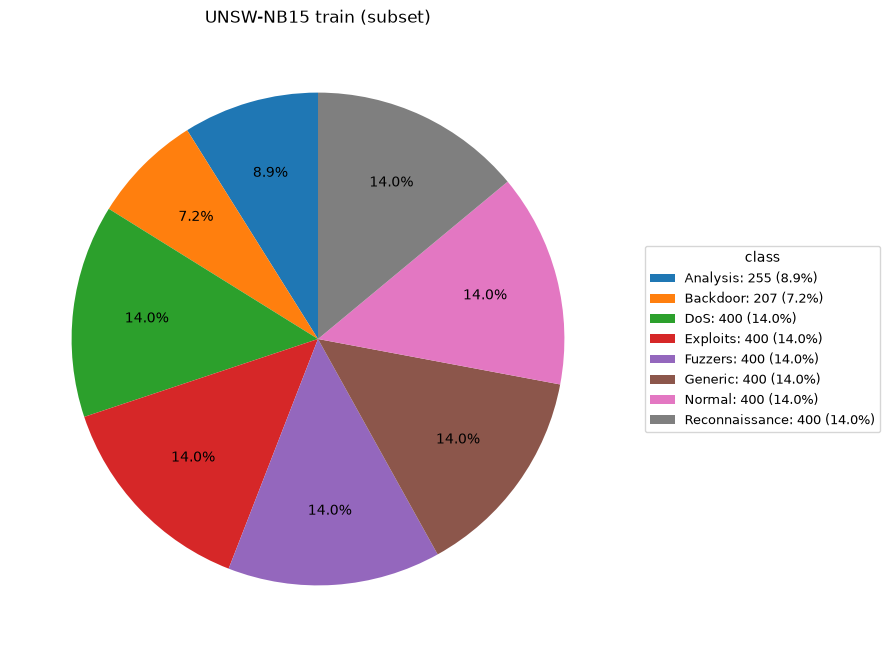

In [14]:
# pie chart
_ = plot_class_balance_pie(y_train, class_names, title=f"{dataset} train (subset)" if SUBSET else f"{dataset} train")
plt.show()

## Quantum Circuit: Angle Encoding, Data Reuploading, and Adding Noise

$x\xrightarrow[\text{encode}]{\phi(x)}\ket{\psi(x)}\xrightarrow[\text{variational}]{U(\theta)}\ket{\Phi(x)}\xrightarrow{\Lambda_p}\rho(x)$
- $x$: classical data
- $\phi(x)$: `qp.AngleEmbedding()`
- $\ket{\psi(x)}$: quantum state after encoding
- $U(\theta)$: `qp.StronglyEntanglingLayers()`
- $\ket{\Phi(x)}$: quantum state after variational transform
- $\rho(x)=\Lambda_p(\ket{\Phi(x)}\bra{\Phi(x)})$: standard depolarization channel to model NISQ noise

In [15]:
num_layers = 2                  # reupload same classical data
noise_rate = DEFAULT_NOISE_RATE

In [16]:
# initialize devices
device = get_torch_device()
dev = create_quantum_device(num_qubits) # or dev = qp.device("default.mixed", wires=num_qubits)

# define circuit
forward_circuit = build_forward_circuit(dev, num_qubits, num_layers, noise_rate=noise_rate)

## Load Day-16 Encoder + $L_\varphi$

Reuse the Day-16 MAQT checkpoint ($\theta^\star$, prototypes) and published $L_\varphi$.

Set `LOAD_CHECKPOINT = False` only to retrain as a fallback.

In [17]:
LOAD_CHECKPOINT = True
CHECKPOINT_CANDIDATES = [
    Path("models/prototypes") / dataset / f"{DAY16_NOTEBOOK}-checkpoint.pt",
]
LPHI_CANDIDATES = [
    Path("models/prototypes") / dataset / f"{DAY16_NOTEBOOK}-lphi.pt",
]

epochs = 10
batch_size = DEFAULT_BATCH_SIZE
lr = DEFAULT_LR
lambda1 = DEFAULT_LAMBDA1
lambda2 = DEFAULT_LAMBDA2
Cf = DEFAULT_CF
alpha = DEFAULT_ALPHA

In [18]:
ckpt_path = next((p for p in CHECKPOINT_CANDIDATES if p.exists()), None)
lphi_path = next((p for p in LPHI_CANDIDATES if p.exists()), None)
history = {}
head = None

# use model checkpoint if loading is enabled and a valid file exists
if LOAD_CHECKPOINT and ckpt_path is not None:
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    theta_star = ckpt["theta"].to(device)
    if not isinstance(theta_star, torch.nn.Parameter):
        theta_star = torch.nn.Parameter(theta_star)
    prototypes = {int(k): v.to(device) for k, v in ckpt["prototypes"].items()}
    noise_rate = float(ckpt.get("noise_rate", noise_rate))
    num_layers = int(ckpt.get("num_layers", num_layers))

    # rebuild circuit if checkpoint meta differs
    forward_circuit = build_forward_circuit(dev, num_qubits, num_layers, noise_rate=noise_rate)
    print(f"loaded checkpoint: {ckpt_path}")
    print(f"theta shape: {tuple(theta_star.shape)} | prototypes: {len(prototypes)}")

# train from scratch if checkpoint loading is disabled or no checkpoint exists
else:
    if LOAD_CHECKPOINT:
        print("checkpoint not found; falling back to MAQT train")
    theta, head, prototypes, ema_protos, history = train_maqt(
        X_train, y_train,
        n_classes=num_classes,
        n_qubits=num_qubits,
        n_layers=num_layers,
        forward_circuit=forward_circuit,
        device=device,
        epochs=epochs,
        lr=lr,
        batch_size=batch_size,
        lambda1_max=lambda1,
        lambda2_max=lambda2,
        use_weighted_sampler=True,
    )
    theta_star = theta
    print(f"trained encoder: theta shape={tuple(theta_star.shape)} | prototypes={len(prototypes)}")

loaded checkpoint: models/prototypes/UNSW-NB15/16.estimate-lipschitz_unsw-nb15-checkpoint.pt
theta shape: (2, 8, 3) | prototypes: 8


In [19]:
# load Day-16 L_phi
if lphi_path is not None:
    lphi_art = torch.load(lphi_path, map_location="cpu", weights_only=False)
    L_phi = float(lphi_art["L_phi_analytic"])
    L_phi_percentile = float(lphi_art.get("L_phi_percentile", 95.0))
    print(f"loaded L_phi from: {lphi_path}")
    print(f"L_phi analytic = {L_phi:.4f}")
else:
    raise FileNotFoundError(
        f"Day-16 L_phi artifact not found under models/prototypes/{dataset}/. "
        "Run 16.estimate-lipschitz_ciciot2023.ipynb first."
    )

loaded L_phi from: models/prototypes/UNSW-NB15/16.estimate-lipschitz_unsw-nb15-lphi.pt
L_phi analytic = 1.0000


In [20]:
# load Day-18 eps* marker (formal H3 cross-check is Day 20)
prop2_path = Path("models/prototypes") / dataset / f"{DAY18_NOTEBOOK}-prop2.pt"
eps_star_ref = None
eps_star_beta_ref = None
if prop2_path.exists():
    prop2_art = torch.load(prop2_path, map_location="cpu", weights_only=False)
    eps_star_ref = prop2_art.get("eps_star_fmax")
    eps_star_beta_ref = prop2_art.get("eps_star_beta_fmax")
    print(f"loaded Day-18 eps*_fmax      = {eps_star_ref}")
    print(f"loaded Day-18 eps*_beta_fmax = {eps_star_beta_ref}")
else:
    print("Day-18 prop2 artifact not found; skip eps* markers")

loaded Day-18 eps*_fmax      = -0.49860895999043175
loaded Day-18 eps*_beta_fmax = -0.49653402597506135


## Calibrate Conformal $q$ (for accept / reject)

A known sample is misflagged when an attack pushes its novelty score past the conformal threshold $q$, so Algorithm 3 labels it `ZERO_DAY` instead of a known class.

$$
s(x)=1-F_{\max}(x),\qquad q = s_{(k)},\quad k=\lceil(1-\alpha)(n+1)\rceil
$$

In [21]:
# calibrate on known calibration split
q, scores_sorted = calibrate_threshold(
    theta_star, X_cal, prototypes, forward_circuit,
    alpha=alpha, device=device, batch_size=batch_size,
)
p = float(noise_rate)

print(f"dataset : {dataset}")
print(f"alpha / q : {alpha} / {q:.6f}")
print(f"p / L_phi / C_f : {p} / {L_phi:.4f} / {Cf}")
print(f"n_cal: {len(to_np_y(y_cal))} | n_test: {len(to_np_y(y_test))}")
print(f"cal scores: min={scores_sorted.min():.4f} max={scores_sorted.max():.4f}")

dataset : UNSW-NB15
alpha / q : 0.05 / 0.547779
p / L_phi / C_f : 0.01 / 1.0000 / 1.0
n_cal: 10112 | n_test: 10086
cal scores: min=0.0000 max=0.8408


## FGSM / PGD on Novelty Score

Attack maximizes $s(x)=1-F_{\max}(x)$ (CQ-ZDR boundary), not classifier-head CE as in `12.fgsm-pgd-*.ipynb`.

### Metrics

- **acceptance rate**: fraction with $\hat y \neq$ `ZERO_DAY`
- **robust accuracy**: fraction with $\hat y = y$ (rejected counts as wrong)
- **empirical breakpoint**: smallest $\varepsilon_2$ where acceptance drops below `BREAKPOINT_ACCEPT`

### Norms

Attacks are $\ell_\infty$ with feature clamp $[0,\pi]$. Report $\varepsilon_2\le\sqrt{d}\,\varepsilon_\infty$ ($d=8$).

In [22]:
N_KNOWN_ACCEPTED = 300          # known accepted test subset size
BREAKPOINT_ACCEPT = 0.99        # breakpoint when acceptance falls below this

EPS_INF_FGSM = [0.0, 0.01, 0.02, 0.05, 0.08, 0.1, 0.15, 0.2, 0.3]
EPS_INF_PGD  = [0.0, 0.05, 0.1, 0.2]

FGSM_BATCH = 16                 # attack backprop is heavy -> smaller than train batch size
PGD_BATCH  = 1
PGD_STEPS  = 3                  # fewer steps = less eigh stress

ANGLE_MIN, ANGLE_MAX = 0.0, float(np.pi)

rng = np.random.default_rng(SEED)

In [23]:
# select currently-accepted known test samples (clean)
y_pred_clean, _, _, _ = qsnet_infer_batch(
    X_test, theta_star, prototypes, q, forward_circuit,
    p=p, L_phi=L_phi, Cf=Cf, zero_day=ZERO_DAY,
    device=device, batch_size=batch_size,
)
y_true = to_np_y(y_test).astype(int)
accepted_mask = y_pred_clean != ZERO_DAY
accepted_idx = np.where(accepted_mask)[0]

if len(accepted_idx) == 0:
    raise RuntimeError("no accepted known-test samples at calibrated q; cannot run Day-19 sweep")

n_take = min(N_KNOWN_ACCEPTED, len(accepted_idx))
pick = rng.choice(accepted_idx, size=n_take, replace=False)
X_attack = np.asarray(X_test[pick], dtype=np.float32)
y_attack = y_true[pick]

print(f"accepted on clean test: {accepted_mask.sum()} / {len(y_true)}")
print(f"attacking subset: {len(X_attack)}")
print(f"clean subset acceptance: {1.0:.4f}")
print(f"clean subset accuracy: {float(np.mean(y_pred_clean[pick] == y_attack)):.4f}")

accepted on clean test: 9551 / 10086
attacking subset: 300
clean subset acceptance: 1.0000
clean subset accuracy: 0.4433


In [24]:
def eval_under_attack(X_adv_np, y_true_np):
    labels, _, scores, _ = qsnet_infer_batch(
        X_adv_np, theta_star, prototypes, q, forward_circuit,
        p=p, L_phi=L_phi, Cf=Cf, zero_day=ZERO_DAY,
        device=device, batch_size=batch_size,
    )
    accepted = labels != ZERO_DAY
    acc = float(np.mean(labels == y_true_np))
    return {
        "acceptance_rate": float(accepted.mean()),
        "robust_acc": acc,
        "mean_novelty": float(np.mean(scores)),
        "n_rejected": int((~accepted).sum()),
    }


def run_eps_sweep(attack_name):
    _, proto_stack = stack_prototypes(prototypes, device=device)
    eps_list = EPS_INF_FGSM if attack_name == "fgsm" else EPS_INF_PGD
    batch_size = FGSM_BATCH if attack_name == "fgsm" else PGD_BATCH

    rows = []
    t0 = time.time()
    for eps_inf in eps_list:
        eps_l2 = float(linf_to_l2_budget(eps_inf, d=num_qubits))

        if eps_inf == 0.0:
            X_adv_np = X_attack
        elif attack_name == "fgsm":
            X_adv = fgsm_attack_nonconformity(
                X_attack, theta_star, prototypes, forward_circuit,
                eps=eps_inf, device=device, x_min=ANGLE_MIN, x_max=ANGLE_MAX,
                batch_size=batch_size, proto_stack=proto_stack,
            )
            X_adv_np = X_adv.detach().cpu().numpy()
        elif attack_name == "pgd":
            alpha = max(eps_inf / PGD_STEPS, 1e-4)
            X_adv = pgd_attack_nonconformity(
                X_attack, theta_star, prototypes, forward_circuit,
                eps=eps_inf, alpha=alpha, steps=PGD_STEPS,
                device=device, x_min=ANGLE_MIN, x_max=ANGLE_MAX,
                batch_size=batch_size, proto_stack=proto_stack,
            )
            X_adv_np = X_adv.detach().cpu().numpy()
        else:
            raise ValueError(attack_name)

        metrics = eval_under_attack(X_adv_np, y_attack)
        rows.append({
            "attack": attack_name,
            "eps_inf": float(eps_inf),
            "eps_l2": eps_l2,
            **metrics,
        })
        print(
            f"[{attack_name}] eps_inf={eps_inf:.3f} eps_l2={eps_l2:.4f} | "
            f"accept={metrics['acceptance_rate']:.4f} "
            f"robust_acc={metrics['robust_acc']:.4f} "
            f"rejected={metrics['n_rejected']}"
        )
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    print(f"[{attack_name}] sweep done in {time.time() - t0:.1f}s")
    return pd.DataFrame(rows)


def empirical_breakpoint(df_attack, thresh=BREAKPOINT_ACCEPT):
    below = df_attack[df_attack["acceptance_rate"] < thresh]
    if len(below) == 0:
        return float("inf")
    return float(below["eps_l2"].iloc[0])

In [25]:
df_fgsm = run_eps_sweep("fgsm")
bp_fgsm = empirical_breakpoint(df_fgsm)
print(f"FGSM empirical breakpoint (L2, acceptance < {BREAKPOINT_ACCEPT:g}): {bp_fgsm:.4f}")
df_fgsm

[fgsm] eps_inf=0.000 eps_l2=0.0000 | accept=1.0000 robust_acc=0.4433 rejected=0
[fgsm] eps_inf=0.010 eps_l2=0.0283 | accept=1.0000 robust_acc=0.4500 rejected=0
[fgsm] eps_inf=0.020 eps_l2=0.0566 | accept=1.0000 robust_acc=0.4533 rejected=0
[fgsm] eps_inf=0.050 eps_l2=0.1414 | accept=0.9933 robust_acc=0.4500 rejected=2
[fgsm] eps_inf=0.080 eps_l2=0.2263 | accept=0.9900 robust_acc=0.4633 rejected=3
[fgsm] eps_inf=0.100 eps_l2=0.2828 | accept=0.9833 robust_acc=0.4700 rejected=5
[fgsm] eps_inf=0.150 eps_l2=0.4243 | accept=0.9800 robust_acc=0.4700 rejected=6
[fgsm] eps_inf=0.200 eps_l2=0.5657 | accept=0.9767 robust_acc=0.4700 rejected=7
[fgsm] eps_inf=0.300 eps_l2=0.8485 | accept=0.9367 robust_acc=0.4433 rejected=19
[fgsm] sweep done in 2277.1s
FGSM empirical breakpoint (L2, acceptance < 0.99): 0.2828


,attack,eps_inf,eps_l2,acceptance_rate,robust_acc,mean_novelty,n_rejected
0,fgsm,0.00,0.000000,1.000000,0.443333,0.186250,0
1,fgsm,0.01,0.028284,1.000000,0.450000,0.189577,0
2,fgsm,0.02,0.056569,1.000000,0.453333,0.193031,0
3,fgsm,0.05,0.141421,0.993333,0.450000,0.204386,2
4,fgsm,0.08,0.226274,0.990000,0.463333,0.216905,3
5,fgsm,0.10,0.282843,0.983333,0.470000,0.225920,5
6,fgsm,0.15,0.424264,0.980000,0.470000,0.250967,6
7,fgsm,0.20,0.565685,0.976667,0.470000,0.278854,7
8,fgsm,0.30,0.848528,0.936667,0.443333,0.341548,19


In [26]:
df_pgd = run_eps_sweep("pgd")
bp_pgd = empirical_breakpoint(df_pgd)
print(f"PGD empirical breakpoint (L2, acceptance < {BREAKPOINT_ACCEPT:g}): {bp_pgd:.4f}")
df_pgd

[pgd] eps_inf=0.000 eps_l2=0.0000 | accept=1.0000 robust_acc=0.4433 rejected=0
[pgd] eps_inf=0.050 eps_l2=0.1414 | accept=0.9933 robust_acc=0.4467 rejected=2
[pgd] eps_inf=0.100 eps_l2=0.2828 | accept=0.9867 robust_acc=0.4700 rejected=4
[pgd] eps_inf=0.200 eps_l2=0.5657 | accept=0.9767 robust_acc=0.4633 rejected=7
[pgd] sweep done in 3110.8s
PGD empirical breakpoint (L2, acceptance < 0.99): 0.2828


,attack,eps_inf,eps_l2,acceptance_rate,robust_acc,mean_novelty,n_rejected
0,pgd,0.00,0.000000,1.000000,0.443333,0.186250,0
1,pgd,0.05,0.141421,0.993333,0.446667,0.200273,2
2,pgd,0.10,0.282843,0.986667,0.470000,0.216990,4
3,pgd,0.20,0.565685,0.976667,0.463333,0.258545,7


In [27]:
def _mark_eps(ax, value, color, style, label):
    if value is None:
        return
    v = float(value)
    if np.isfinite(v) and v > 0:
        ax.axvline(v, color=color, linestyle=style, label=label)
    elif np.isfinite(v) and v <= 0:
        ax.text(
            0.02, 0.02,
            f"{label}: no positive radius ({v:.3f})",
            transform=ax.transAxes, fontsize=8, color=color,
            va="bottom",
        )

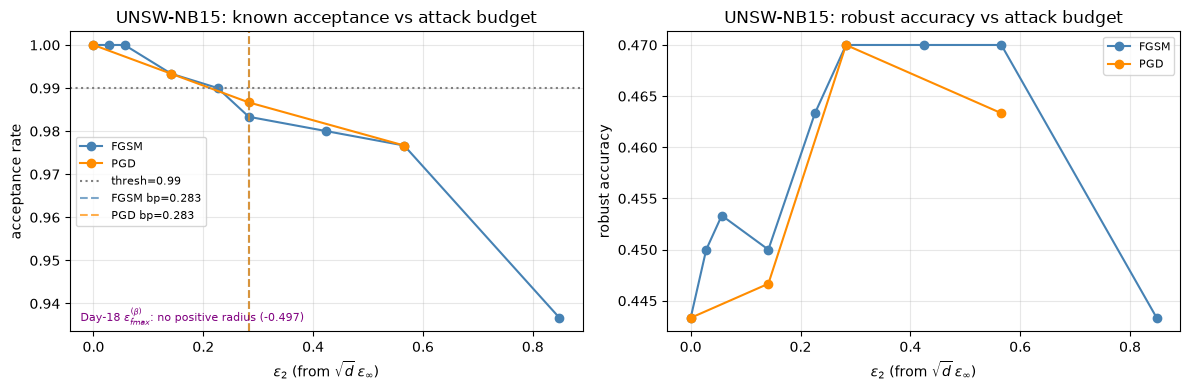

In [28]:
# plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for df_a, name, color in [
    (df_fgsm, "FGSM", "steelblue"),
    (df_pgd, "PGD", "darkorange"),
]:
    axes[0].plot(df_a["eps_l2"], df_a["acceptance_rate"], marker="o", color=color, label=name)
    axes[1].plot(df_a["eps_l2"], df_a["robust_acc"], marker="o", color=color, label=name)

axes[0].axhline(BREAKPOINT_ACCEPT, color="gray", linestyle=":", label=f"thresh={BREAKPOINT_ACCEPT:g}")
if np.isfinite(bp_fgsm):
    axes[0].axvline(bp_fgsm, color="steelblue", linestyle="--", alpha=0.7, label=f"FGSM bp={bp_fgsm:.3f}")
if np.isfinite(bp_pgd):
    axes[0].axvline(bp_pgd, color="darkorange", linestyle="--", alpha=0.7, label=f"PGD bp={bp_pgd:.3f}")

# plot eps* line or not
# if eps_star_ref is not None and np.isfinite(float(eps_star_ref)):
#     axes[0].axvline(float(eps_star_ref), color="green", linestyle="-.",
#                     label=fr"Day-18 $\varepsilon^*$={float(eps_star_ref):.3f}")
#
# _mark_eps(axes[0], eps_star_ref, "green", "-.",
#           fr"Day-18 $\varepsilon^*_{{fmax}}$")
_mark_eps(axes[0], eps_star_beta_ref, "purple", ":",
          fr"Day-18 $\varepsilon^{{(\beta)}}_{{fmax}}$")

axes[0].set_xlabel(r"$\varepsilon_2$ (from $\sqrt{d}\,\varepsilon_\infty$)")
axes[0].set_ylabel("acceptance rate")
axes[0].set_title(rf"{dataset}: known acceptance vs attack budget")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel(r"$\varepsilon_2$ (from $\sqrt{d}\,\varepsilon_\infty$)")
axes[1].set_ylabel("robust accuracy")
axes[1].set_title(rf"{dataset}: robust accuracy vs attack budget")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
summary_df = pd.DataFrame({
    "quantity": [
        "n_attack", "alpha", "q", "accept_thresh",
        "bp_fgsm_l2", "bp_pgd_l2",
        "eps_star_day18", "eps_star_beta_day18",
        "L_phi", "p", "C_f",
        "fgsm_accept_at_0", "fgsm_accept_at_max",
        "pgd_accept_at_0", "pgd_accept_at_max",
    ],
    "value": [
        len(X_attack), alpha, q, BREAKPOINT_ACCEPT,
        bp_fgsm, bp_pgd,
        eps_star_ref, eps_star_beta_ref, L_phi, p, Cf,
        float(df_fgsm.iloc[0]["acceptance_rate"]),
        float(df_fgsm.iloc[-1]["acceptance_rate"]),
        float(df_pgd.iloc[0]["acceptance_rate"]),
        float(df_pgd.iloc[-1]["acceptance_rate"]),
    ],
})
summary_df

,quantity,value
0,n_attack,300.000000
1,alpha,0.050000
2,q,0.547779
3,accept_thresh,0.990000
4,bp_fgsm_l2,0.282843
5,bp_pgd_l2,0.282843
6,eps_star_day18,-0.498609
7,eps_star_beta_day18,-0.496534
8,L_phi,1.000000
9,p,0.010000


## Prototypes

In [30]:
proto_df = pd.DataFrame(prototype_summary(prototypes, class_names))
proto_df

,class,dim,trace
0,Analysis,256,1.0
1,Backdoor,256,1.0
2,DoS,256,1.0
3,Exploits,256,1.0
4,Fuzzers,256,1.0
5,Generic,256,1.0
6,Normal,256,1.0
7,Reconnaissance,256,1.0


## Logging

In [31]:
# save Day-19 robustness artifact
out_dir = Path("models/prototypes") / dataset
out_dir.mkdir(parents=True, exist_ok=True)

artifact = {
    "dataset": dataset,
    "notebook": NOTEBOOK_NAME,
    "noise_rate (p)": float(p),
    "L_phi": float(L_phi),
    "C_f": float(Cf),
    "alpha": float(alpha),
    "q": float(q),
    "accept_thresh": float(BREAKPOINT_ACCEPT),
    "attack_pick": np.asarray(pick, dtype=np.int64),  # indices into X_test
    "n_accepted_clean": int(accepted_mask.sum()),
    "clean_subset_acc": float(np.mean(y_pred_clean[pick] == y_attack)),
    "pgd_steps": int(PGD_STEPS),
    "bp_fgsm_l2": None if not np.isfinite(bp_fgsm) else float(bp_fgsm),
    "bp_pgd_l2": None if not np.isfinite(bp_pgd) else float(bp_pgd),
    "eps_star_day18": None if eps_star_ref is None else float(eps_star_ref),
    "eps_star_beta_day18": None if eps_star_beta_ref is None else float(eps_star_beta_ref),
    "fgsm_rows": df_fgsm.to_dict(orient="records"),
    "pgd_rows": df_pgd.to_dict(orient="records"),
    "checkpoint": None if ckpt_path is None else str(ckpt_path),
    "lphi_path": None if lphi_path is None else str(lphi_path),
    "prop2_path": str(prop2_path) if prop2_path.exists() else None,
}

robust_path = out_dir / f"{NOTEBOOK_NAME}-artifact.pt"
torch.save(artifact, robust_path)
print("published robustness:", robust_path.resolve())

published robustness: /home/lawun330/Desktop/quantum-sentinel/models/prototypes/UNSW-NB15/19.fgsm-pgd-robustness_unsw-nb15-artifact.pt


In [32]:
# write log (final)
log_path = write_history_log(
    history if history else {"bp_fgsm_l2": [None if not np.isfinite(bp_fgsm) else float(bp_fgsm)]},
    NOTEBOOK_NAME,
    extra={
        ## data
        "data_path": data_path,
        "dataset": dataset,
        "split_prefix": split_prefix,
        "target_col": target_col,
        "n_train": len(X_train),
        "n_cal": len(X_cal),
        "n_test": int(len(X_test)),
        "n_attack": int(len(X_attack)),
        "per_class_cap": PER_CLASS_CAP if SUBSET else None,
        "class_names": list(class_names),

        ## quantum model
        "noise_rate (p)": float(p),
        "num_layers": int(num_layers),
        "num_qubits": int(num_qubits),
        "num_classes": int(num_classes),

        ## day 19
        "L_phi": float(L_phi),
        "C_f": float(Cf),
        "alpha": float(alpha),
        "q": float(q),
        "accept_thresh": float(BREAKPOINT_ACCEPT),
        "bp_fgsm_l2": None if not np.isfinite(bp_fgsm) else float(bp_fgsm),
        "bp_pgd_l2": None if not np.isfinite(bp_pgd) else float(bp_pgd),
        "eps_star_day18": None if eps_star_ref is None else float(eps_star_ref),
        "eps_star_beta_day18": None if eps_star_beta_ref is None else float(eps_star_beta_ref),

        "checkpoint": str(ckpt_path) if ckpt_path is not None else None,
        "lphi_path": str(lphi_path) if lphi_path is not None else None,
    },
    log_dir="logs",
)
print(f"wrote {log_path.resolve()}")

wrote /home/lawun330/Desktop/quantum-sentinel/logs/19.fgsm-pgd-robustness_unsw-nb15.log
